# Time Series forecasting

## Task Decomposition

1) Exploratory Data Analysis (EDA): Examine trends, seasonality, and anomalies in energy consumption over time.

2) Time Series Decomposition: Decompose the series into trend, seasonality, and residual components.

3) Modeling: Apply forecasting models such as ARIMA, SARIMA, Prophet, or LSTM to predict future energy consumption.

4) Visualization: Create plots to visualize consumption patterns and forecast results.

### Part 1: Exploratory Data Analysis (EDA): Examine trends, seasonality, and anomalies in energy consumption over time.

Original shape: (145366, 2)
Original columns: ['Datetime', 'PJME_MW']
⚠️  Duplicate timestamps found: 4
✅ Shape after dedupe: (145362, 2)
Final shape: (145362, 1)

First 3 rows:
                     consumption
dt                              
2002-01-01 01:00:00      30393.0
2002-01-01 02:00:00      29265.0
2002-01-01 03:00:00      28357.0

📈 Summary:
count    145362.000000
mean      32080.505139
std        6463.874131
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: consumption, dtype: float64


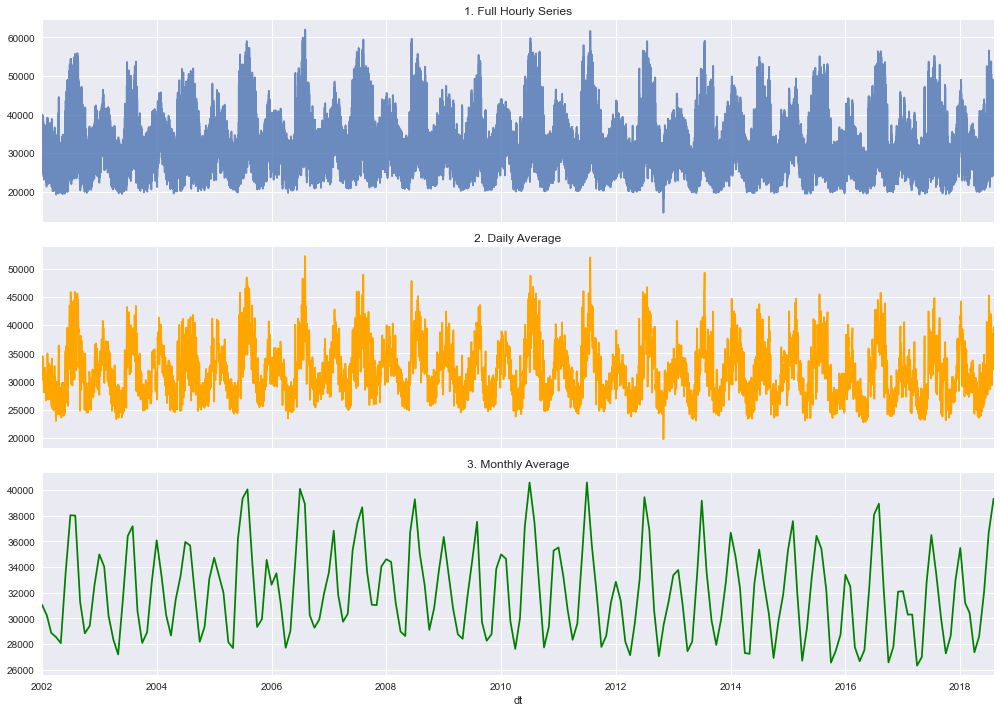

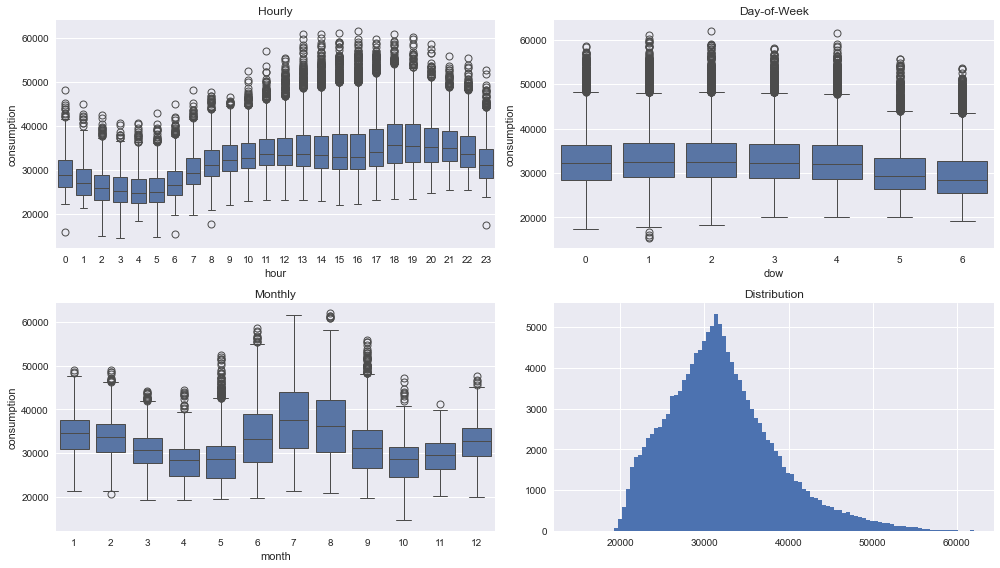

🚨 Anomalies: 1318 (0.9%)


In [23]:
## PART 1: EXPLORATORY DATA ANALYSIS - DUPLICATE-FIXED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

# 1.1 LOAD & CLEAN DUPLICATES
df = pd.read_csv('pjme_hourly.csv')
print("Original shape:", df.shape)
print("Original columns:", df.columns.tolist())

# Convert & check for duplicates BEFORE setting index
df['Datetime'] = pd.to_datetime(df['Datetime'])
dupe_count = df['Datetime'].duplicated().sum()
print(f"⚠️  Duplicate timestamps found: {dupe_count}")

# REMOVE DUPLICATES (keep first occurrence)
df = df.drop_duplicates(subset='Datetime', keep='first').reset_index(drop=True)
print("✅ Shape after dedupe:", df.shape)

# Now safe to set index
df = df.rename(columns={'Datetime': 'dt', 'PJME_MW': 'consumption'})
df = df.set_index('dt').sort_index()
print("Final shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

# 1.2 BASIC STATS & TRENDS
print("\n📈 Summary:")
print(df['consumption'].describe())

daily = df['consumption'].resample('D').mean()
monthly = df['consumption'].resample('ME').mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df['consumption'].plot(ax=axes[0], title='1. Full Hourly Series', alpha=0.8)
daily.plot(ax=axes[1], title='2. Daily Average', color='orange')
monthly.plot(ax=axes[2], title='3. Monthly Average', color='green')
plt.tight_layout()
plt.show()

# 1.3 SEASONALITY
df['hour'] = df.index.hour
df['dow'] = df.index.dayofweek
df['month'] = df.index.month

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=df.sample(50000), x='hour', y='consumption', ax=axes[0,0])
axes[0,0].set_title('Hourly')
sns.boxplot(data=df.sample(50000), x='dow', y='consumption', ax=axes[0,1])
axes[0,1].set_title('Day-of-Week')
sns.boxplot(data=df.sample(50000), x='month', y='consumption', ax=axes[1,0])
axes[1,0].set_title('Monthly')
df['consumption'].hist(bins=100, ax=axes[1,1])
axes[1,1].set_title('Distribution')
plt.tight_layout()
plt.show()

# 1.4 ANOMALIES
df['zscore'] = (df['consumption'] - df['consumption'].mean()) / df['consumption'].std()
anomalies = df[np.abs(df['zscore']) > 3]
print(f"🚨 Anomalies: {len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)")

### Part 2: Time Series Decomposition

## DECOMPOSITION RESULTS ##


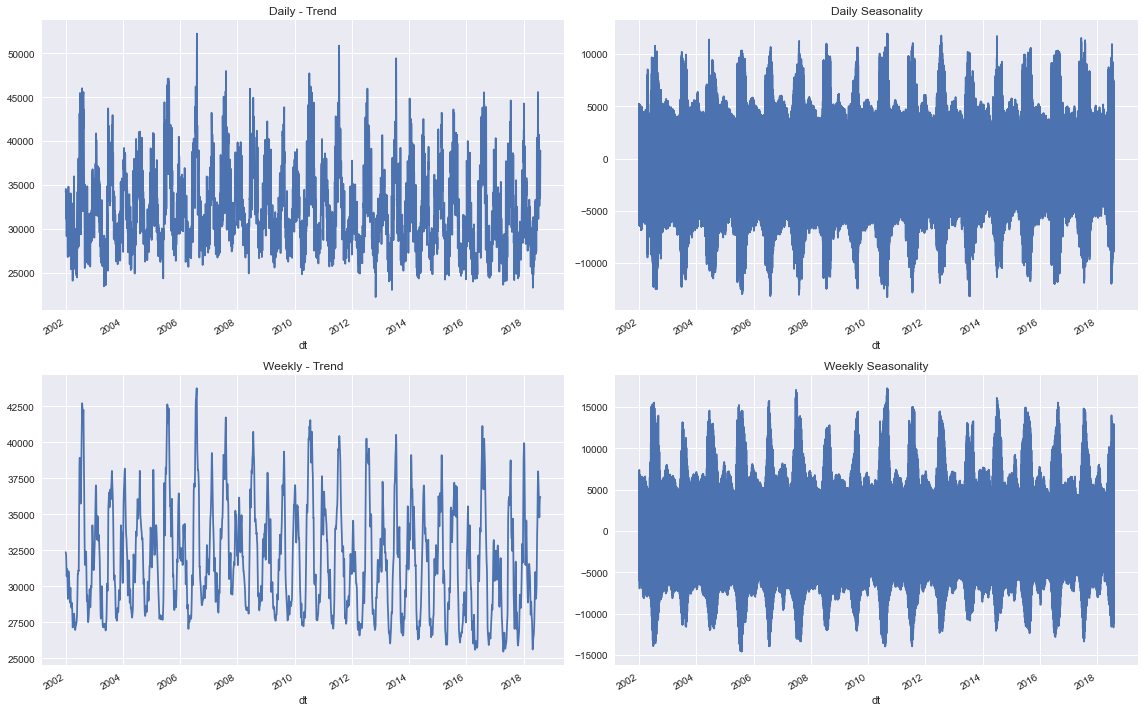

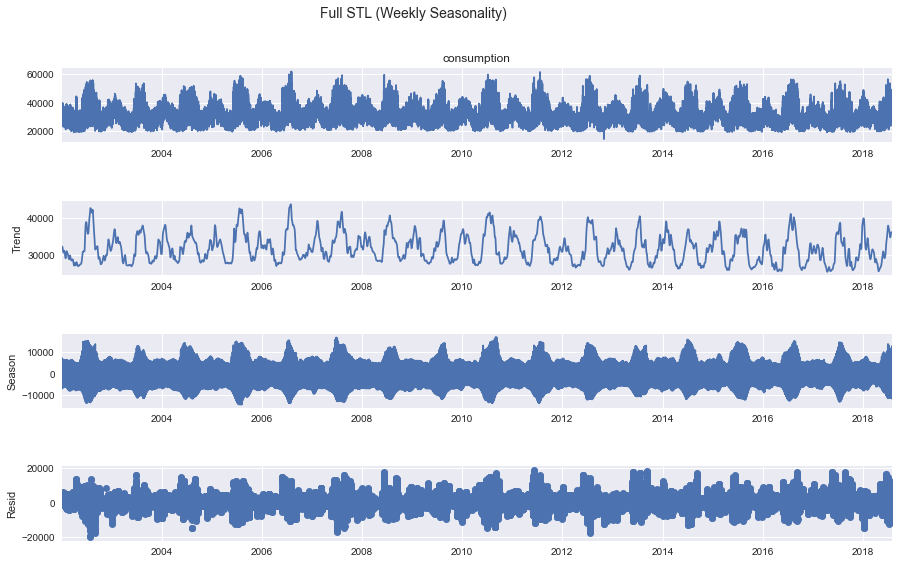

✅ Decomposition complete


In [24]:
## PART 2: STL DECOMPOSITION (runs after Part 1)

from statsmodels.tsa.seasonal import STL

print("## DECOMPOSITION RESULTS ##")

# Multiple seasonalities
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

stl_daily = STL(df['consumption'], period=24, robust=True).fit()
stl_daily.trend.plot(ax=axes[0,0], title='Daily - Trend')
stl_daily.seasonal.plot(ax=axes[0,1], title='Daily Seasonality')

stl_weekly = STL(df['consumption'], period=168, robust=True).fit()  # 24*7
stl_weekly.trend.plot(ax=axes[1,0], title='Weekly - Trend')
stl_weekly.seasonal.plot(ax=axes[1,1], title='Weekly Seasonality')

plt.tight_layout()
plt.show()

# Full decomposition
res = STL(df['consumption'], period=168, robust=True).fit()
fig = res.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Full STL (Weekly Seasonality)', y=1.02, fontsize=14)
plt.show()

print("✅ Decomposition complete")


### Part 3: Modeling

In [ ]:
## PART 3: FORECASTING MODELS

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Train/test split
H = 24 * 7  # 1 week
y = df['consumption'].dropna()
train = y.iloc[:-H]
test = y.iloc[-H:]

print(f"Train: {len(train):,} | Test: {H} hours")

# SARIMA
sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,24),
                enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)
sarima_forecast = sarima_res.forecast(steps=H)
mae_sarima = mean_absolute_error(test, sarima_forecast)

# Prophet
prophet_df = train.reset_index()[['dt', 'consumption']].rename(columns={'dt':'ds', 'consumption':'y'})
test_p = test.reset_index()[['dt', 'consumption']].rename(columns={'dt':'ds', 'consumption':'y'})

m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
m.fit(prophet_df)
future_p = m.make_future_dataframe(periods=H, freq='h')
forecast_p = m.predict(future_p)
prophet_forecast = forecast_p.set_index('ds')['yhat'].iloc[-H:]
mae_prophet = mean_absolute_error(test_p['y'], prophet_forecast)

# Results
results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet'],
    'MAE_MW': [mae_sarima.round(1), mae_prophet.round(1)]
})
print("\n🏆 Model Comparison:")
print(results)
print(f"Best: {results.iloc[results['MAE_MW'].idxmin()]['Model']}")

# Store for Part 4
globals().update(locals())


### Part 4: Visualization + Final Forecasts

In [1]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

df = (
    pd.read_csv("pjme_hourly.csv")  # your file
      .rename(columns={"Datetime": "dt", "PJME_MW": "consumption"})
)
df["dt"] = pd.to_datetime(df["dt"])
df = df.sort_values("dt").set_index("dt")

df.info()
df["consumption"].describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   consumption  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: consumption, dtype: float64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   consumption  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


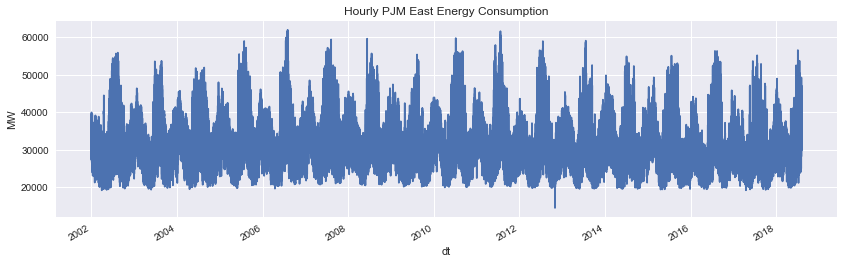

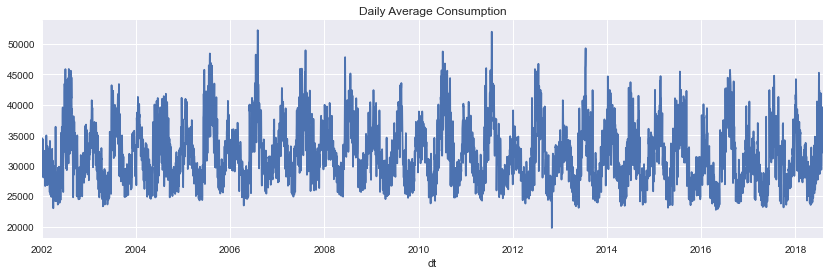

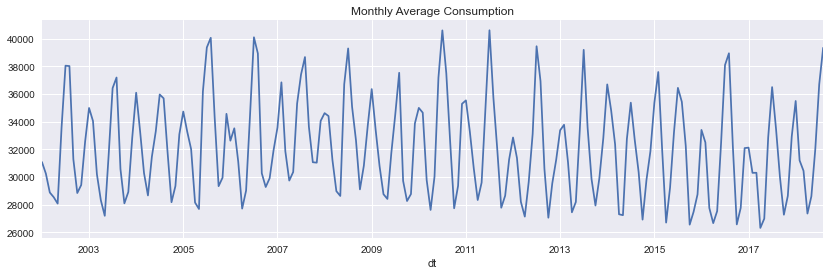

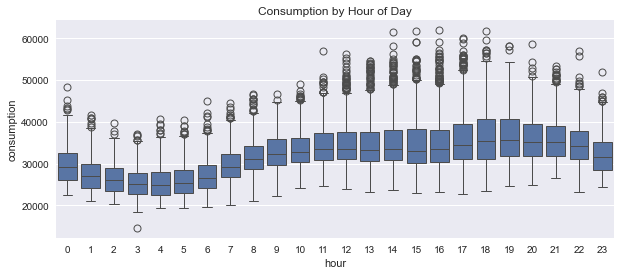

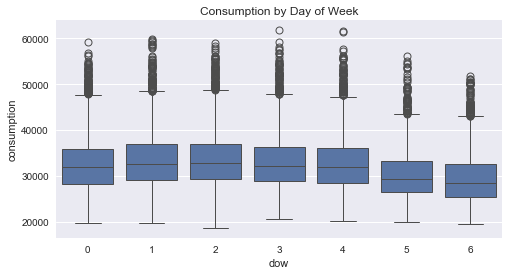

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
df["consumption"].plot(ax=ax)
ax.set_title("Hourly PJM East Energy Consumption")
ax.set_ylabel("MW")
plt.show()

# Daily average
daily = df["consumption"].resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax)
ax.set_title("Daily Average Consumption")
plt.show()

# Monthly average
monthly = df["consumption"].resample("ME").mean()
fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax)
ax.set_title("Monthly Average Consumption")
plt.show()

# Hour-of-day and day-of-week seasonality
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek  # 0=Mon

plt.figure(figsize=(10,4))
sns.boxplot(data=df.sample(20000), x="hour", y="consumption")
plt.title("Consumption by Hour of Day")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df.sample(20000), x="dow", y="consumption")
plt.title("Consumption by Day of Week")
plt.show()


In [17]:
import numpy as np

df["z"] = (df["consumption"] - df["consumption"].mean()) / df["consumption"].std()
anomalies = df[np.abs(df["z"]) > 3]


In [19]:
from statsmodels.tsa.seasonal import STL

# Ensure regular hourly frequency
s = df["consumption"].asfreq("H")

stl = STL(s, period=24*7, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
fig.suptitle("STL Decomposition (Weekly Seasonality)", y=1.02)
plt.show()


/var/folders/1w/fxwbqyv52h5bq4v1v80dmd4w0000gn/T/ipykernel_46445/3295261747.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s = df["consumption"].asfreq("H")


ValueError: cannot reindex on an axis with duplicate labels

In [2]:
# upload data & rename columns

df = pd.read_csv('pjme_hourly.csv').rename(columns = {'Datetime':'dt', 'PJME_MW':'consumption'})
df.head()

,dt,consumption
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


**We will creat some time series features to see how the trends are impacted by day of week, hour, time of year, etc.**

In [3]:
import pandas as pd

def create_features(df, datetime_col='dt', label=None):
    """
    Creates time series features from a datetime column with snake_case names.
    """
    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])  # ensure datetime
    
    df['hour'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek
    df['quarter'] = df[datetime_col].dt.quarter
    df['month'] = df[datetime_col].dt.month
    df['year'] = df[datetime_col].dt.year
    df['day_of_year'] = df[datetime_col].dt.dayofyear
    df['day_of_month'] = df[datetime_col].dt.day
    df['week_of_year'] = df[datetime_col].dt.isocalendar().week

    X = df[['hour','day_of_week','quarter','month','year',
            'day_of_year','day_of_month','week_of_year']]
    
    if label:
        y = df[label]
        return X, y
    return X

# Usage
X, y = create_features(df, datetime_col='dt', label='consumption')
features_and_target = pd.concat([X, y], axis=1)
features_and_target.head()


,hour,day_of_week,quarter,month,year,day_of_year,day_of_month,week_of_year,consumption
0,1,1,4,12,2002,365,31,1,26498.0
1,2,1,4,12,2002,365,31,1,25147.0
2,3,1,4,12,2002,365,31,1,24574.0
3,4,1,4,12,2002,365,31,1,24393.0
4,5,1,4,12,2002,365,31,1,24860.0


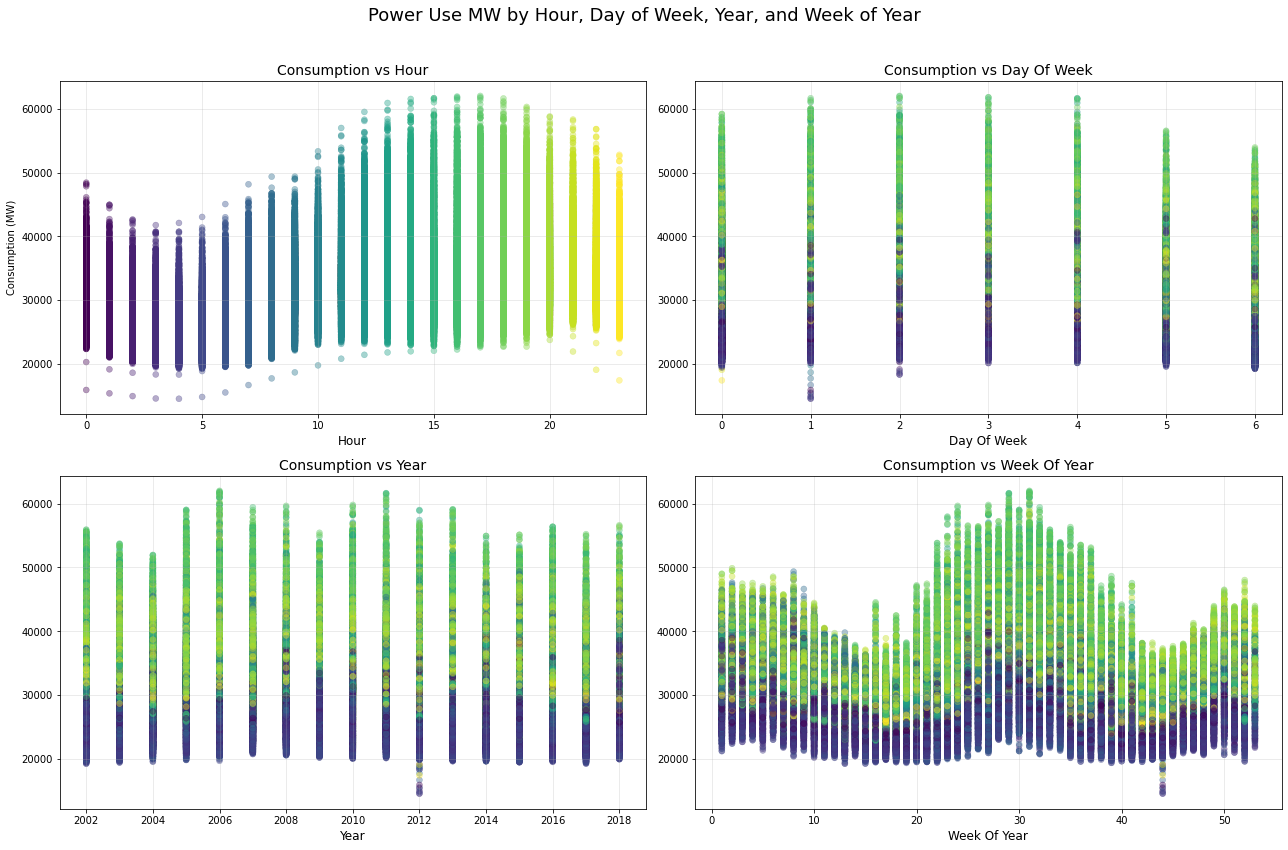

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['hour', 'day_of_week', 'year', 'week_of_year']
target = 'consumption'

plt.figure(figsize=(18, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        data=features_and_target.dropna(),
        x=feature,
        y=target,
        hue='hour',
        palette='viridis',
        alpha=0.4,
        edgecolor=None,
        legend=False
    )
    plt.xlabel(feature.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Consumption (MW)' if i == 1 else '')
    plt.title(f'{target.title()} vs {feature.replace("_", " ").title()}', fontsize=14)
    plt.grid(alpha=0.3)

plt.suptitle('Power Use MW by Hour, Day of Week, Year, and Week of Year', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [6]:
df['dt'] = pd.to_datetime(df['dt'])  # Ensure it's datetime dtype
df = df.set_index('dt')              # This makes index DatetimeIndex
df = df.sort_index()                 # Sort if needed


In [9]:
# Daily average
daily = df['consumption'].resample('D').mean()

# Or STL decomposition
from statsmodels.tsa.seasonal import STL
stl = STL(df['consumption'], period=168).fit()  # 168 = 24*7


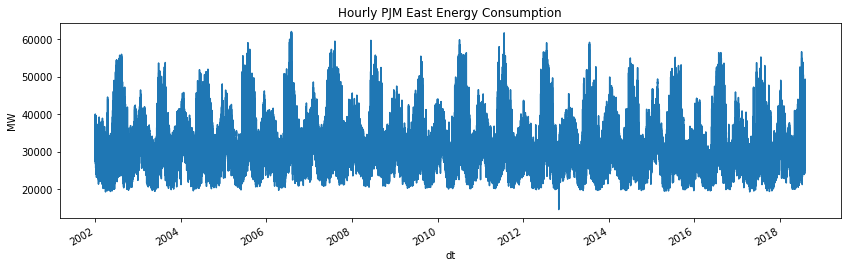

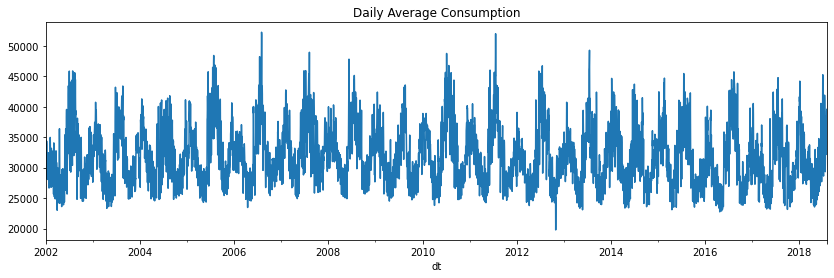

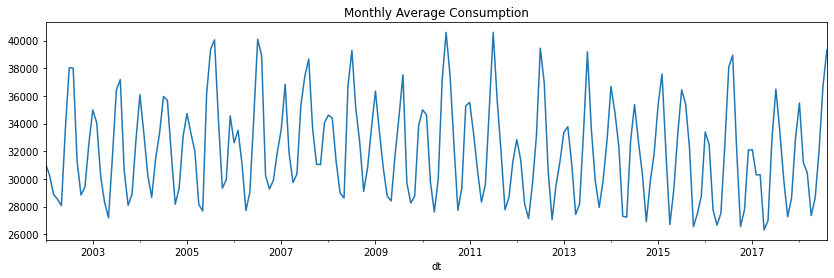

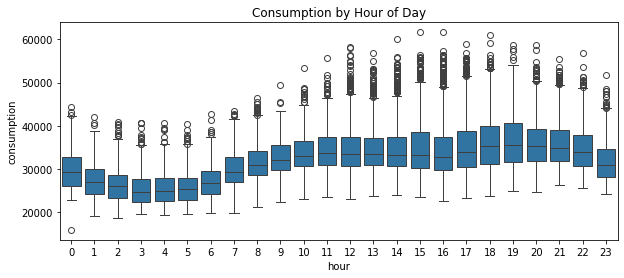

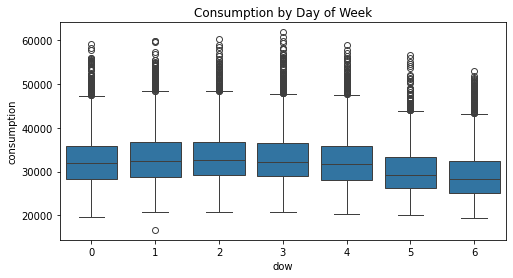

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
df["consumption"].plot(ax=ax)
ax.set_title("Hourly PJM East Energy Consumption")
ax.set_ylabel("MW")
plt.show()

# Daily average
daily = df["consumption"].resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax)
ax.set_title("Daily Average Consumption")
plt.show()

# Monthly average
monthly = df["consumption"].resample("ME").mean()
fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax)
ax.set_title("Monthly Average Consumption")
plt.show()

# Hour-of-day and day-of-week seasonality
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek  # 0=Mon

plt.figure(figsize=(10,4))
sns.boxplot(data=df.sample(20000), x="hour", y="consumption")
plt.title("Consumption by Hour of Day")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df.sample(20000), x="dow", y="consumption")
plt.title("Consumption by Day of Week")
plt.show()
